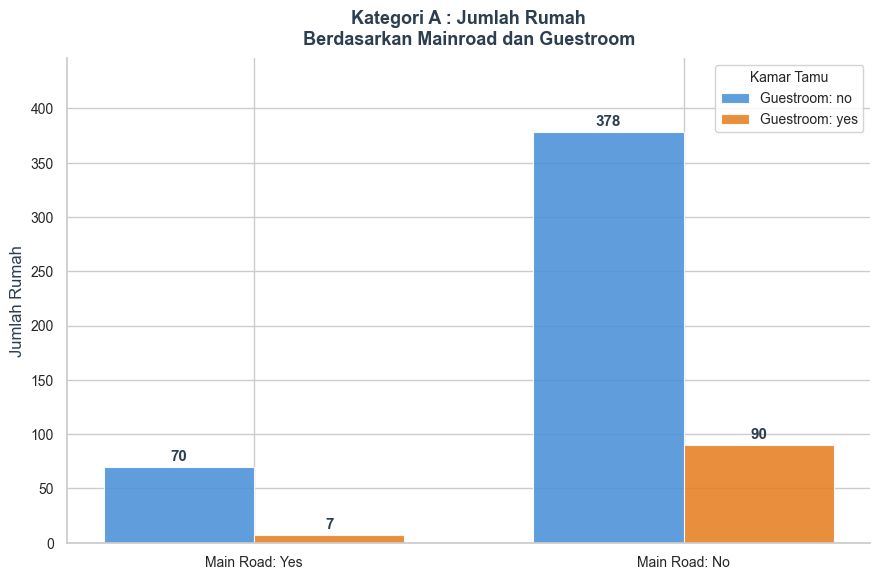

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Load dataset ────────────────────────────────────────────
df = pd.read_csv("Kelas C_Housing.csv")

# ── Style ──────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
BLUE   = "#4A90D9"
ORANGE = "#E67E22"
ACCENT = "#2C3E50"

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_facecolor('#FFFFFF')

grp_a = (df.groupby(['mainroad', 'guestroom'])
           .size()
           .reset_index(name='count'))

x_labels = grp_a['mainroad'].unique()
x = np.arange(len(x_labels))
width = 0.35
guestroom_vals = grp_a['guestroom'].unique()
colors_a = [BLUE, ORANGE]

for i, groom in enumerate(guestroom_vals):
    sub = grp_a[grp_a['guestroom'] == groom]
    counts = [sub[sub['mainroad'] == ml]['count'].values[0]
              if ml in sub['mainroad'].values else 0
              for ml in x_labels]
    bars = ax.bar(x + i * width - width / 2, counts, width,
                   label=f'Guestroom: {groom}',
                   color=colors_a[i], edgecolor='white', linewidth=0.8,
                   alpha=0.88)
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                 str(val), ha='center', va='bottom', fontsize=11,
                 fontweight='bold', color=ACCENT)

ax.set_xticks(x)
ax.set_xticklabels(['Main Road: Yes', 'Main Road: No'], fontsize=12)
ax.set_ylabel('Jumlah Rumah', fontsize=12, color=ACCENT)
ax.set_title('Kategori A : Jumlah Rumah\nBerdasarkan Mainroad dan Guestroom',
             fontsize=13, fontweight='bold', color=ACCENT, pad=10)
ax.legend(title='Kamar Tamu', fontsize=10, title_fontsize=10,
          framealpha=0.85, loc='upper right')
ax.set_ylim(0, grp_a['count'].max() * 1.18)
ax.tick_params(axis='both', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()